## Sprint 3 - Analisis exploratorio de datos

### Analisis de dato abiertos (movilidad)

In [2]:
# Importar librerias necesarias para analisis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### validacion_SITP

In [3]:
# 1. Cargar el dataset de validaciones
df_sitp = pd.read_csv('../datos_limpios/validacion_SITP.csv')

In [4]:
# 2. Agrupar los datos: contar cuantas validaciones hay por cada acceso en cada estacion
agrupado = df_sitp.groupby(['estacion_parada', 'acceso_estacion']).size().reset_index(name='cantidad')
# Ordenar de mayor a menor para que el gráfico sea más fácil de leer
agrupado = agrupado.sort_values(by='cantidad', ascending=False)

#### Visualizar variables

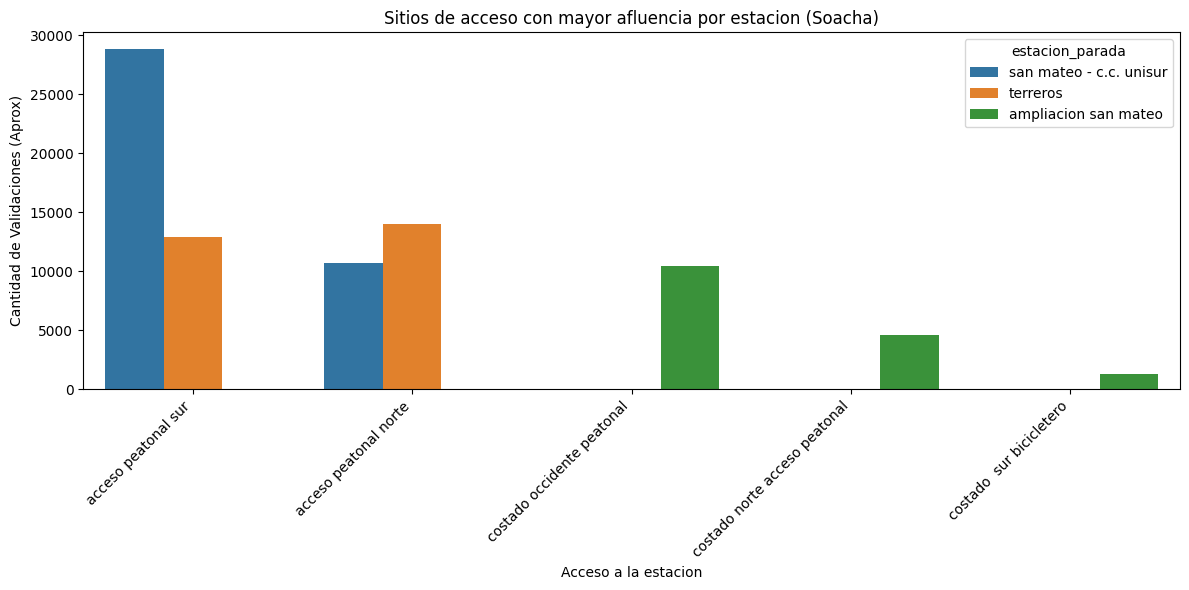

In [6]:
# 5. Crear el grafico con Seaborn y Matplotlib
plt.figure(figsize=(12, 6)) # Tamaño de la figura
sns.barplot(data=agrupado, x='acceso_estacion', y='cantidad', hue='estacion_parada')

# 6. Personalizar titulos y etiquetas
plt.title('Sitios de acceso con mayor afluencia por estacion (Soacha)')
plt.xticks(rotation=45, ha='right') # Rotar el texto del eje X para que no se superponga
plt.ylabel('Cantidad de Validaciones (Aprox)')
plt.xlabel('Acceso a la estacion')
plt.tight_layout() # Ajustar los márgenes automáticamente

# 7. Mostrar el grafico
plt.show()

### Promedios tiempo y desplazamiento

In [6]:
# 1. Cargar el dataset de tiempos promedio
df_tiempo = pd.read_csv('../datos_limpios/Tiempo_promedio.csv')
df_velocidad = pd.read_csv('../datos_limpios/Velocidad_promedio.csv')

In [7]:
# 2. Unificar las columnas para tener un solo marco de datos historico completo
# En Velocidad_promedio, la columna 'tiempo' equivale a los minutos para recorrer 10km 
df_vel_subset = df_velocidad[['ano', 'velocidad_promedio_km/h', 'tiempo']].rename(
    columns={'velocidad_promedio_km/h': 'velocidad_kmh', 'tiempo': 'minutos_10km'}
)

# En Tiempo_promedio, renombramos para que coincidan
df_tiempo_subset = df_tiempo[['ano', 'velocidad_km/h', 'minutos_en_10_kilometros_recorridos']].rename(
    columns={'velocidad_km/h': 'velocidad_kmh', 'minutos_en_10_kilometros_recorridos': 'minutos_10km'}
)

# Unimos todo en un solo DataFrame historico
df_historico_completo = pd.concat([df_vel_subset, df_tiempo_subset], ignore_index=True)

In [8]:
# 3. Calcular promedios historicos (2002 - 2025)
promedio_vel_historica = df_historico_completo['velocidad_kmh'].mean()
promedio_tiempo_historico = df_historico_completo['minutos_10km'].mean()

In [9]:
# 4. Calcular promedios recientes (2022 - 2025) usando solo el dataset de Tiempo_promedio
promedio_vel_reciente = df_tiempo_subset['velocidad_kmh'].mean()
promedio_tiempo_reciente = df_tiempo_subset['minutos_10km'].mean()

In [10]:
# 5. Validación de la hipotesis (60 a 90 minutos) con datos recientes
# Regla de 3: (Minutos de viaje / Minutos que toma hacer 10km) * 10 km
distancia_60_min = (60 / promedio_tiempo_reciente) * 10
distancia_90_min = (90 / promedio_tiempo_reciente) * 10

In [11]:
# 6. Imprimir los resultados
print("--- PROMEDIOS HISTORICOS (2002-2025) ---")
print(f"Velocidad promedio historica: {promedio_vel_historica:.2f} km/h")
print(f"Tiempo promedio para 10 km histórico: {promedio_tiempo_historico:.2f} minutos\n")

print("--- PROMEDIOS RECIENTES (2022-2025) ---")
print(f"Velocidad promedio actual: {promedio_vel_reciente:.2f} km/h")
print(f"Tiempo promedio para 10 km actual: {promedio_tiempo_reciente:.2f} minutos\n")

print("--- Hipotesis - Tiempos de recorrido en bogota ---")
print(f"Distancia recorrida en 60 min a velocidad actual: {distancia_60_min:.2f} km")
print(f"Distancia recorrida en 90 min a velocidad actual: {distancia_90_min:.2f} km")

--- PROMEDIOS HISTORICOS (2002-2025) ---
Velocidad promedio historica: 21.06 km/h
Tiempo promedio para 10 km histórico: 29.45 minutos

--- PROMEDIOS RECIENTES (2022-2025) ---
Velocidad promedio actual: 16.57 km/h
Tiempo promedio para 10 km actual: 36.33 minutos

--- Hipotesis - Tiempos de recorrido en bogota ---
Distancia recorrida en 60 min a velocidad actual: 16.52 km
Distancia recorrida en 90 min a velocidad actual: 24.78 km


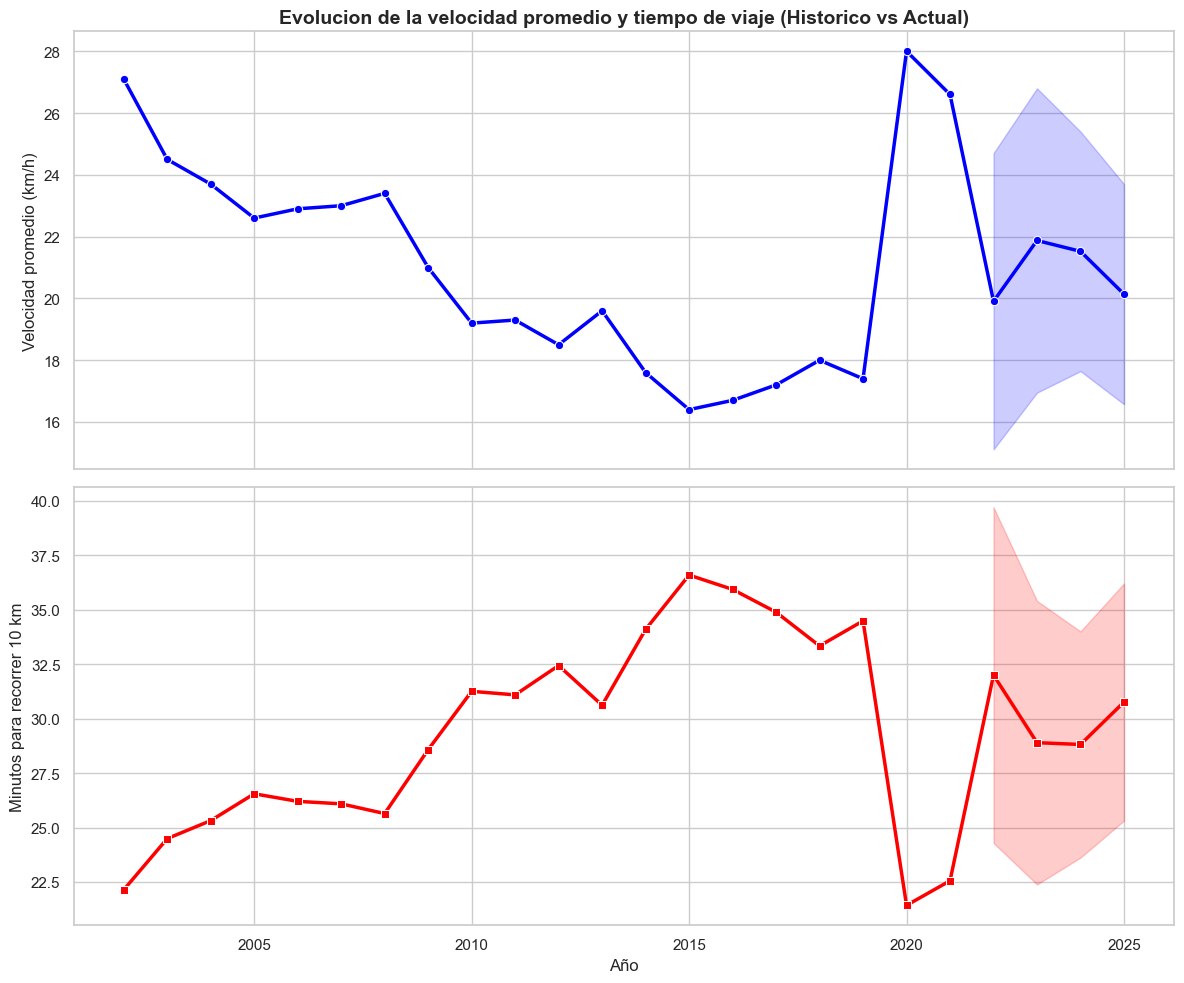

In [12]:
# 3. Configurar la visualizacion
sns.set_theme(style="whitegrid") # Estilo con cuadrícula de fondo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True) # generamos dos graficos, uno arriba del otro

# subplot 1: Velocidad
sns.lineplot(data=df_historico_completo, x='ano', y='velocidad_kmh', marker='o', ax=ax1, color='blue', linewidth=2.5)
ax1.set_title('Evolucion de la velocidad promedio y tiempo de viaje (Historico vs Actual)', fontsize=14, weight='bold')
ax1.set_ylabel('Velocidad promedio (km/h)', fontsize=12)

# subplot 2: Tiempo de viaje
sns.lineplot(data=df_historico_completo, x='ano', y='minutos_10km', marker='s', ax=ax2, color='red', linewidth=2.5)
ax2.set_ylabel('Minutos para recorrer 10 km', fontsize=12)
ax2.set_xlabel('Año', fontsize=12)

# Ajustar el diseño para que no se superpongan los textos
plt.tight_layout()

# Mostrar el grafico
plt.show()